<a href="https://colab.research.google.com/github/Ke1thuzad/vk_practice/blob/main/VK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import datasets
import torch
import hdbscan
import numpy as np
import umap

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = SentenceTransformer("deepvk/USER-bge-m3", device=device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [ ]:
ds = datasets.load_dataset("deepvk/ru-WANLI", split="train[:5000]")

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/val.parquet:   0%|          | 0.00/391k [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/791k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2360 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
sent = ds['premise']

In [ ]:
len(sent), max([len(i) for i in sent])

(5000, 424)

In [ ]:
model.max_seq_length = 1024

In [ ]:
embeddings = model.encode(sent, batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True,
    device=device)

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
X = embeddings.to('cpu')

# Попробуем реализовать кластеризацию на основе KMeans и PCA, а затем визуализируем с помощью t-SNE

In [ ]:
pca = PCA(50)
ts = TSNE()
X_pca = pca.fit_transform(X)
X_ts = ts.fit_transform(X_pca)

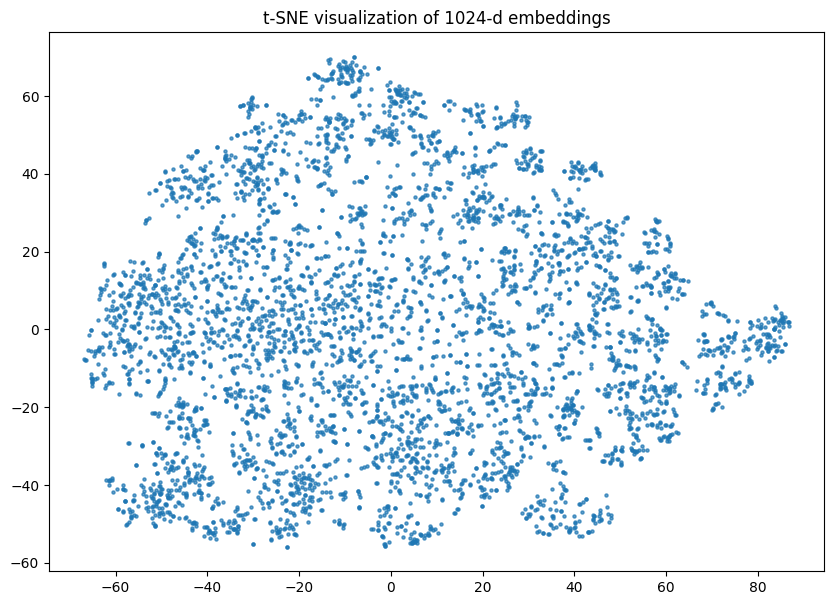

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_ts[:, 0], X_ts[:, 1], s=5, alpha=0.7)
plt.title("t-SNE visualization of 1024-d embeddings")
plt.show()

In [ ]:
distortions = []

for cluster in range(2, 10):
  km = KMeans(cluster)
  km.fit(X_pca)
  distortions.append(km.inertia_)

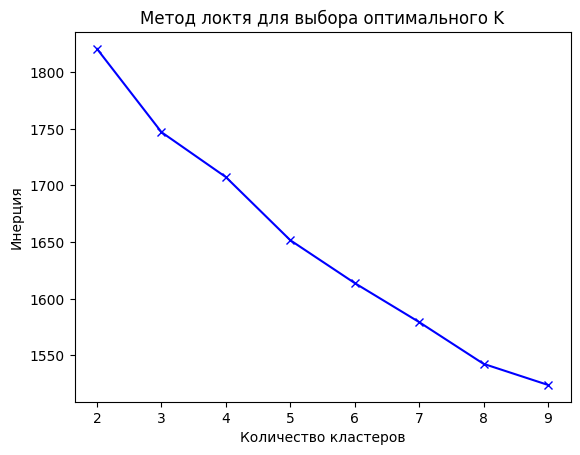

In [ ]:
plt.plot(range(2, 10), distortions, 'bx-')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.title('Метод локтя для выбора оптимального K')
plt.show()

## На графике видно, что метод локтя работает очень плохо, но всё равно возьмем что-то близкое, например, 4 кластера.

In [ ]:
km = KMeans(4)

labels = km.fit_predict(X_pca)

In [ ]:
tsne = TSNE()
embd2d = tsne.fit_transform(X_pca)

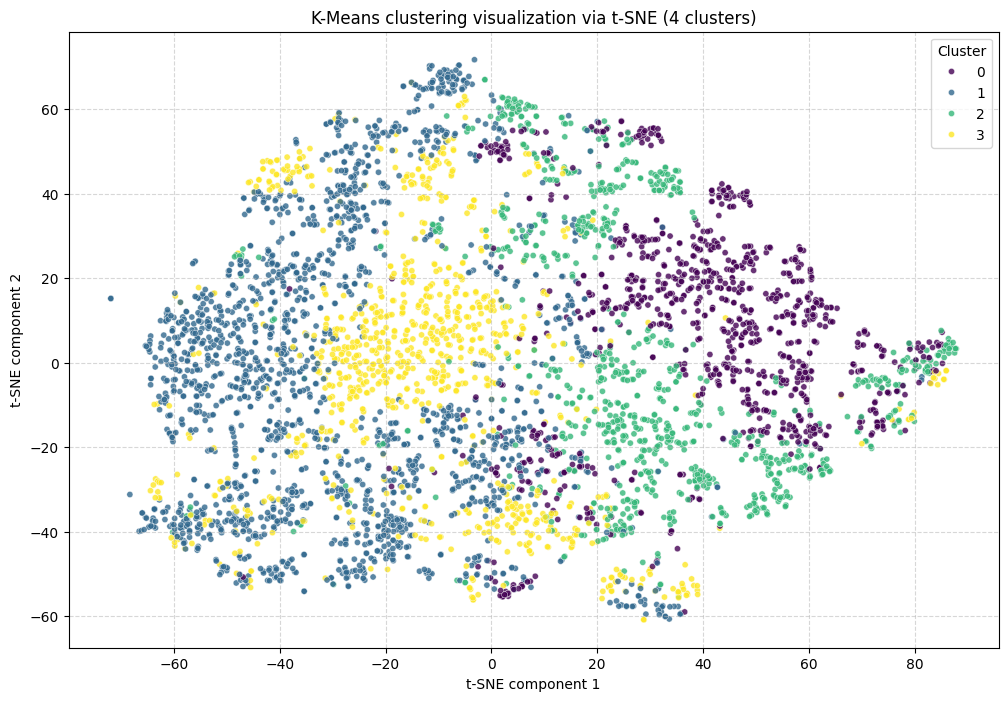

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=embd2d[:, 0],
    y=embd2d[:, 1],
    hue=labels,
    palette='viridis',
    legend='full',
    alpha=0.8,
    s=20
)

plt.title(f'K-Means clustering visualization via t-SNE ({4} clusters)')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
for i, l in enumerate(labels[:10]):
  print(sent[i], l)

GM предполагает что прокуроры из Гессена занимаются шпионажем в отношении GM но это обвинение не подтверждено. 3
Этот фильм получил много негативных отзывов. 3
Группа людей находится на пикнике в лесу наслаждаясь природой и готовя шашлыки на углях. 0
Мужчина крепит крючок на стене с помощью отвертки. 2
Я не могу поверить что ты всё ещё используешь старую технику в то время как другие уже перешли на современное оборудование это как жить в прошлом. 3
Мы отправились в поход в горы и не взяли с собой достаточно еды. 3
Наш банк предоставляет широкий выбор продуктов для управления вашими финансами включая кредитные карты ипотечные кредиты и сберегательные счета. 1
Летняя Олимпиада 2020 проходила в Токио Япония. Более 11 тысяч спортсменов со всего мира приехали чтобы участвовать в спортивных соревнованиях. 1
Я люблю гулять в парке на рассвете когда тишина и только пение птиц разбудили меня. 1
Уличный художник создал настоящее произведение искусства на стене заброшенного здания. 2


## Кластеризация очень непонятная, 4 кластеров точно недостаточно для получения внятного результата и KMeans не способен разделить данные так хорошо.

## Попробуем вместо него использовать более SOTA модель - HDBSCAN. Она самостоятельно ищет оптимальное количество кластеров.

In [ ]:
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, gen_min_span_tree=True)

In [ ]:
hdb_labels = hdb.fit_predict(X_pca)

In [ ]:
tsne = TSNE()
embd2d = tsne.fit_transform(X_pca)

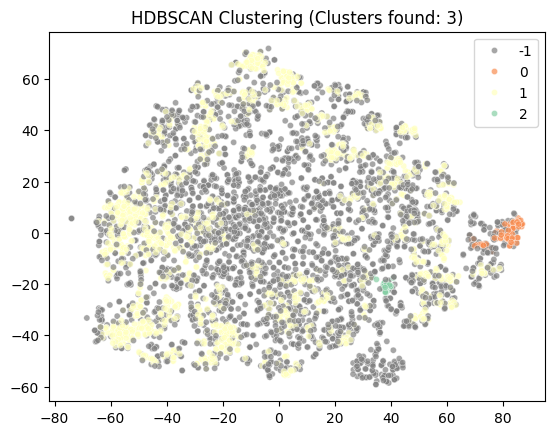

In [ ]:
unique_labels = set(hdb_labels)
colors = sns.color_palette("Spectral", len(unique_labels) - (1 if -1 in hdb_labels else 0))

sns.scatterplot(
    x=embd2d[:, 0],
    y=embd2d[:, 1],
    hue=hdb_labels,
    palette=['#808080'] + list(colors) if -1 in hdb_labels else colors,
    hue_order=sorted(unique_labels),
    s=20,
    alpha=0.7,
    legend='full'
)

plt.title(f"HDBSCAN Clustering (Clusters found: {len(unique_labels) - (1 if -1 in hdb_labels else 0)})")
plt.show()

## На данном графике можем заметить, что HDBSCAN'у сложно кластеризовать данные, потому что они слишком разбросаны, нет отдельных островков, по которым можно было бы проводить оптимальную кластеризацию

# Попробуем использовать UMAP вместо PCA

In [ ]:
reducer = umap.UMAP(n_neighbors=15, n_components=10, min_dist=0.0, metric='cosine')
embeddings_low_dim = reducer.fit_transform(X)

In [ ]:
tsne = TSNE()
embd2d = tsne.fit_transform(embeddings_low_dim)

In [ ]:
hdb = hdbscan.HDBSCAN(min_cluster_size=75, min_samples=10, gen_min_span_tree=True)
hdb_labels = hdb.fit_predict(embeddings_low_dim)

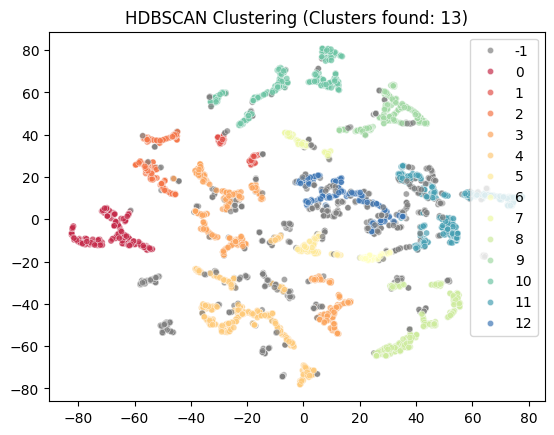

In [ ]:
unique_labels = set(hdb_labels)
colors = sns.color_palette("Spectral", len(unique_labels) - (1 if -1 in hdb_labels else 0))

sns.scatterplot(
    x=embd2d[:, 0],
    y=embd2d[:, 1],
    hue=hdb_labels,
    palette=['#808080'] + list(colors) if -1 in hdb_labels else colors,
    hue_order=sorted(unique_labels),
    s=20,
    alpha=0.7,
    legend='full'
)

plt.title(f"HDBSCAN Clustering (Clusters found: {len(unique_labels) - (1 if -1 in hdb_labels else 0)})")
plt.show()

## Теперь островки отлично сформировались, данные хорошо кластеризованы с помощью UMAP и HDBSCAN.

# Результаты кластеризации

## Выведем все кластеры и просмотрим их содержимое

In [ ]:
sentences_array = np.array(sent)

unique_clusters = sorted(np.unique(hdb_labels))

for cluster_id in unique_clusters:
    cluster_indices = np.where(hdb_labels == cluster_id)[0]

    cluster_size = len(cluster_indices)

    print(f"=== Кластер ID: {cluster_id} | Размер: {cluster_size} ===")

    example_indices = cluster_indices[:5]

    for i, idx in enumerate(example_indices):
        example_text = sentences_array[idx]
        print(f"  {i+1}. {example_text}")

    print("-" * 50)

=== Кластер ID: -1 | Размер: 1080 ===
  1. GM предполагает что прокуроры из Гессена занимаются шпионажем в отношении GM но это обвинение не подтверждено.
  2. Мужчина крепит крючок на стене с помощью отвертки.
  3. Я не могу поверить что ты всё ещё используешь старую технику в то время как другие уже перешли на современное оборудование это как жить в прошлом.
  4. Мы отправились в поход в горы и не взяли с собой достаточно еды.
  5. Летняя Олимпиада 2020 проходила в Токио Япония. Более 11 тысяч спортсменов со всего мира приехали чтобы участвовать в спортивных соревнованиях.
--------------------------------------------------
=== Кластер ID: 0 | Размер: 325 ===
  1. Женщина гладит свою собаку которая лежит на коврике.
  2. Рыжий пес гуляет по побережью выползая из воды и стреляя капли в разные стороны.
  3. Собаки - лучшие друзья человека но некоторые собаки могут быть очень вредными и опасными.
  4. Собака лает на мужчину который ласкает ее за ухом.
  5. В лесу гулял медведь и яростно р

# Чтобы не размечать кластеры вручную, используем LLM для разметки.
Использованная модель - Qwen3.5-2B.

In [ ]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import AutoProcessor, AutoModelForCausalLM

In [ ]:
MODEL_ID = "Qwen/Qwen3.5-2B"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model_llm = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
cluster_names = {}

In [ ]:
import gc

if 'model' in locals():
    del model

gc.collect()
torch.cuda.empty_cache()

## Соберём рандомную коллекцию из 100 предложений для каждого кластера и соберём промпт для LLM, чтобы она определила оптимальное название для них.

In [ ]:
model_llm.eval()

for cluster_id in unique_clusters:
    if cluster_id == -1:
        cluster_names[-1] = "Шум (разрозненные данные)"
        continue

    cluster_indices = np.where(hdb_labels == cluster_id)[0]

    n_samples = min(len(cluster_indices), 50)
    random_indices = np.random.choice(cluster_indices, size=n_samples, replace=False)

    examples = sentences_array[random_indices]
    examples_str = "\n".join([f"- {text[:200]}" for text in examples])

    messages = [
        {"role": "user", "content": f"Ты — эксперт-аналитик. Твоя задача — проанализировать список похожих текстов и придумать одно короткое, обобщающее название для этой группы (не более 3-5 слов). Пиши ТОЛЬКО название и ничего лишнего.\n\nТексты кластера:\n{examples_str}\n\nНазвание кластера:"},
    ]

    prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)

    inputs = processor(text=prompt, return_tensors="pt").to(model_llm.device)
    inputs.pop("mm_token_type_ids", None)

    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    decoded_output = processor.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()

    clean_name = decoded_output.replace('"', '').replace('.', '').split('\n')[0]
    cluster_names[cluster_id] = clean_name

    print(f"Кластер {cluster_id}: {clean_name}")

Кластер 0: Животные
Кластер 1: Чтение книг
Кластер 2: Кухня и еда
Кластер 3: Спорт и тренировки
Кластер 4: Здоровый образ жизни
Кластер 5: Детская игра
Кластер 6: Сюжетные истории
Кластер 7: Романтика и природа
Кластер 8: Автопарк и транспорт
Кластер 9: Книги и фильмы
Кластер 10: Честность и правдивость
Кластер 11: Образование и бизнес
Кластер 12: Одиночество
Кластер 13: Правовые и социальные конфликты


In [ ]:
cluster_names

{-1: 'Шум (разрозненные данные)',
 np.int64(0): 'Животные',
 np.int64(1): 'Чтение книг',
 np.int64(2): 'Кухня и еда',
 np.int64(3): 'Спорт и тренировки',
 np.int64(4): 'Здоровый образ жизни',
 np.int64(5): 'Детская игра',
 np.int64(6): 'Сюжетные истории',
 np.int64(7): 'Романтика и природа',
 np.int64(8): 'Автопарк и транспорт',
 np.int64(9): 'Книги и фильмы',
 np.int64(10): 'Честность и правдивость',
 np.int64(11): 'Образование и бизнес',
 np.int64(12): 'Одиночество',
 np.int64(13): 'Правовые и социальные конфликты'}

In [ ]:
for cluster_id in unique_clusters:
    cluster_indices = np.where(hdb_labels == cluster_id)[0]
    cluster_size = len(cluster_indices)

    name = cluster_names.get(cluster_id, "Без названия")

    print(f"=== {name} ===")
    print(f"ID: {cluster_id} | Размер кластера: {cluster_size} объектов")

    n_examples = min(cluster_size, 5)
    ex_indices = np.random.choice(cluster_indices, size=n_examples, replace=False)

    for i, idx in enumerate(ex_indices):
        example_text = sentences_array[idx][:200]
        print(f"  {i+1}. {example_text}")

    print("-" * 60)

=== Шум (разрозненные данные) ===
ID: -1 | Размер кластера: 1080 объектов
  1. Все эти документы нужно подписать и отправить до конца дня иначе мы будем просрочены.
  2. Некоторые люди считают что работа в офисе - настоящее благо и возможность заработать хорошие деньги.
  3. Несмотря на то что большинство писателей считают публикацию своих произведений важной частью создания литературной карьеры есть и те кто предпочитает уделять больше времени творчеству и не публиковать
  4. Город находился под угрозой опустынивания из-за нехватки воды; Правительство намеревалось ввести контроль над водными ресурсами города чтобы решить проблему.
  5. Школа предоставляет учащимся бесплатные обеды во время обеденного перерыва.
------------------------------------------------------------
=== Животные ===
ID: 0 | Размер кластера: 325 объектов
  1. Кошка спит на окне прижавшись лапами к груди.
  2. Коровы — животные которые давно приручены людьми и выращиваются для мяса и молока. Коровы также используютс

# Названия кластеров довольно достоверно соответствуют предложениям из них. Задача выполнена успешно.